
                    BIENVENIDO AL SOLVER PSO PARA TSP

Solver profesional de optimización para el Problema del Viajero
utilizando Particle Swarm Optimization (PSO)

Desarrollado por: Experto en Optimización

                         PSO PARA TSP - MENÚ PRINCIPAL

[1] Generar ciudades aleatorias
[2] Ingresar ciudades manualmente
[3] Usar ejemplo predefinido (10 ciudades)
[4] Usar ejemplo predefinido (5 ciudades)
[5] Salir


Seleccione una opción: 1

¿Cuántas ciudades? (máximo 10): 5

✓ Generadas 5 ciudades aleatorias

📍 Ciudades cargadas:
   Ciudad 0: (84.26, 38.60)
   Ciudad 1: (23.30, 40.24)
   Ciudad 2: (27.39, 21.57)
   Ciudad 3: (47.21, 10.29)
   Ciudad 4: (86.10, 29.15)

--------------------------------------------------------------------------------
CONFIGURACIÓN DE PARÁMETROS PSO
--------------------------------------------------------------------------------

¿Usar configuración por defecto? (s/n): s

🚀 Iniciando optimización...
PSO PARA TSP - OPTIMIZACIÓN
Ciudades: 5
Partícul

/tmp/ipython-input-1357722139.py:441: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


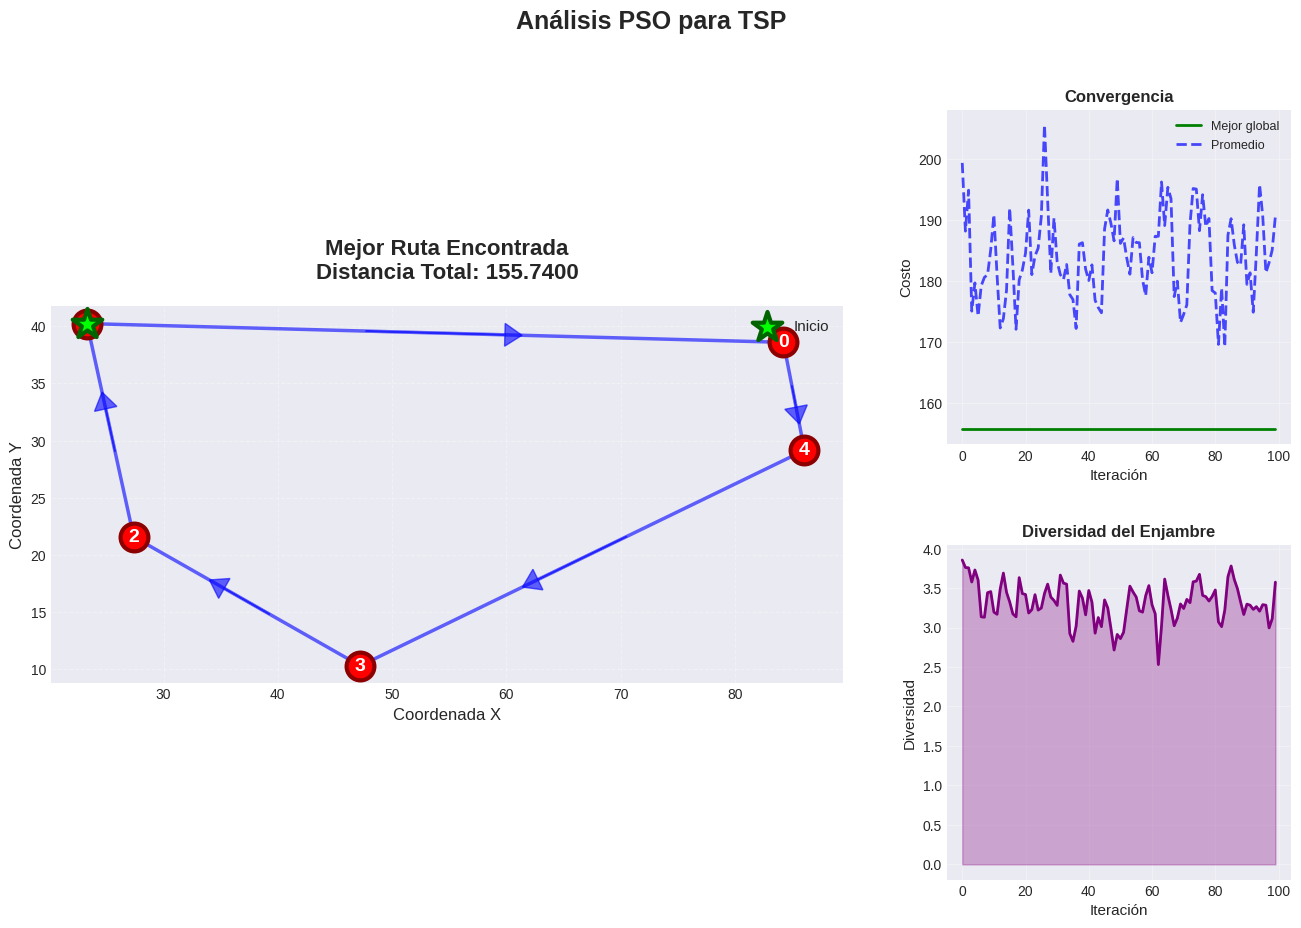


¿Desea resolver otro problema? (s/n): 

In [ ]:
"""
PSO para TSP - Solver Profesional
Optimizado para problemas con hasta 10 ciudades

Autor: Experto en Optimización
Fecha: 2025
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import time
from typing import List, Tuple, Dict
import sys

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

class PSOTSPSolver:
    """
    Particle Swarm Optimization adaptado para TSP

    Características:
    - Representación basada en permutaciones
    - Operadores discretos (swap, insert, reverse)
    - Búsqueda local 2-opt integrada
    - Visualización en tiempo real
    """

    def __init__(self, cities: np.ndarray, n_particles: int = 30,
                 n_iterations: int = 100, w: float = 0.7,
                 c1: float = 1.5, c2: float = 1.5,
                 use_2opt: bool = True, verbose: bool = True):
        """
        Inicializar solver PSO para TSP

        Args:
            cities: Array (n, 2) con coordenadas de ciudades
            n_particles: Tamaño del enjambre
            n_iterations: Número máximo de iteraciones
            w: Coeficiente de inercia
            c1: Coeficiente cognitivo (atracción a pBest)
            c2: Coeficiente social (atracción a gBest)
            use_2opt: Aplicar búsqueda local 2-opt
            verbose: Mostrar progreso
        """
        # Validación
        if len(cities) > 10:
            raise ValueError("Este solver está optimizado para máximo 10 ciudades")
        if len(cities) < 3:
            raise ValueError("Se requieren al menos 3 ciudades")

        self.cities = cities
        self.n_cities = len(cities)
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.use_2opt = use_2opt
        self.verbose = verbose

        # Precalcular matriz de distancias
        self.dist_matrix = self._calculate_distance_matrix()

        # Estado del enjambre
        self.particles = None
        self.velocities = None
        self.pbest_positions = None
        self.pbest_costs = None
        self.gbest_position = None
        self.gbest_cost = float('inf')

        # Historial
        self.history = {
            'gbest_costs': [],
            'avg_costs': [],
            'diversity': [],
            'iterations': []
        }

    def _calculate_distance_matrix(self) -> np.ndarray:
        """Calcular matriz de distancias euclidianas"""
        n = self.n_cities
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                d = np.linalg.norm(self.cities[i] - self.cities[j])
                dist[i, j] = dist[j, i] = d
        return dist

    def _evaluate(self, route: np.ndarray) -> float:
        """Calcular costo (distancia total) de una ruta"""
        cost = 0.0
        for i in range(len(route)):
            city_from = route[i]
            city_to = route[(i + 1) % len(route)]
            cost += self.dist_matrix[city_from, city_to]
        return cost

    def _initialize_particles(self) -> None:
        """Inicializar enjambre con permutaciones aleatorias"""
        self.particles = np.zeros((self.n_particles, self.n_cities), dtype=int)

        for i in range(self.n_particles):
            self.particles[i] = np.random.permutation(self.n_cities)

        # Inicializar velocidades (matriz de swap strength)
        self.velocities = np.random.rand(self.n_particles, self.n_cities) * 0.5

        # Inicializar mejores personales
        self.pbest_positions = self.particles.copy()
        self.pbest_costs = np.array([self._evaluate(p) for p in self.particles])

        # Inicializar mejor global
        best_idx = np.argmin(self.pbest_costs)
        self.gbest_position = self.pbest_positions[best_idx].copy()
        self.gbest_cost = self.pbest_costs[best_idx]

    def _swap_operator(self, route: np.ndarray, target: np.ndarray,
                      strength: float) -> np.ndarray:
        """
        Operador de swap: incorpora características de 'target' en 'route'

        Args:
            route: Ruta actual
            target: Ruta objetivo (pBest o gBest)
            strength: Intensidad de la operación [0, 1]

        Returns:
            Nueva ruta modificada
        """
        new_route = route.copy()
        n_swaps = max(1, int(self.n_cities * strength * np.random.rand()))

        for _ in range(n_swaps):
            # Elegir ciudad aleatoria en target
            city_idx = np.random.randint(self.n_cities)
            target_city = target[city_idx]

            # Encontrar posición actual de esa ciudad en new_route
            current_pos = np.where(new_route == target_city)[0][0]

            # Intercambiar para acercar a la posición en target
            if current_pos != city_idx:
                new_route[current_pos], new_route[city_idx] = \
                    new_route[city_idx], new_route[current_pos]

        return new_route

    def _reverse_operator(self, route: np.ndarray) -> np.ndarray:
        """
        Operador de reversión: invierte un segmento aleatorio (2-opt move)
        """
        new_route = route.copy()
        i, j = sorted(np.random.choice(self.n_cities, 2, replace=False))
        new_route[i:j+1] = new_route[i:j+1][::-1]
        return new_route

    def _insert_operator(self, route: np.ndarray) -> np.ndarray:
        """
        Operador de inserción: mueve una ciudad a otra posición
        """
        new_route = route.copy().tolist()
        i = np.random.randint(self.n_cities)
        j = np.random.randint(self.n_cities)
        city = new_route.pop(i)
        new_route.insert(j, city)
        return np.array(new_route)

    def _apply_2opt(self, route: np.ndarray, max_improvements: int = 20) -> np.ndarray:
        """
        Búsqueda local 2-opt para refinamiento

        Args:
            route: Ruta a mejorar
            max_improvements: Número máximo de mejoras a buscar

        Returns:
            Ruta mejorada
        """
        improved_route = route.copy()
        improved_cost = self._evaluate(improved_route)
        improvements = 0

        for i in range(self.n_cities - 1):
            if improvements >= max_improvements:
                break

            for j in range(i + 2, self.n_cities):
                # Calcular cambio en costo con 2-opt
                # Eliminar aristas (i, i+1) y (j, j+1)
                # Agregar aristas (i, j) y (i+1, j+1)

                city_i = improved_route[i]
                city_i1 = improved_route[i + 1]
                city_j = improved_route[j]
                city_j1 = improved_route[(j + 1) % self.n_cities]

                # Costo actual
                current = (self.dist_matrix[city_i, city_i1] +
                          self.dist_matrix[city_j, city_j1])

                # Costo después de 2-opt
                new = (self.dist_matrix[city_i, city_j] +
                      self.dist_matrix[city_i1, city_j1])

                # Si mejora, aplicar
                if new < current:
                    improved_route[i+1:j+1] = improved_route[i+1:j+1][::-1]
                    improved_cost = self._evaluate(improved_route)
                    improvements += 1
                    break

        return improved_route

    def _calculate_diversity(self) -> float:
        """
        Calcular diversidad del enjambre
        Basado en distancia promedio entre partículas
        """
        diversity = 0.0
        n_comparisons = 0

        for i in range(self.n_particles):
            for j in range(i + 1, self.n_particles):
                # Distancia de Hamming entre permutaciones
                diff = np.sum(self.particles[i] != self.particles[j])
                diversity += diff
                n_comparisons += 1

        return diversity / n_comparisons if n_comparisons > 0 else 0

    def optimize(self) -> Tuple[np.ndarray, float]:
        """
        Ejecutar optimización PSO

        Returns:
            (mejor_ruta, mejor_costo)
        """
        if self.verbose:
            print("="*80)
            print("PSO PARA TSP - OPTIMIZACIÓN")
            print("="*80)
            print(f"Ciudades: {self.n_cities}")
            print(f"Partículas: {self.n_particles}")
            print(f"Iteraciones: {self.n_iterations}")
            print(f"Parámetros: w={self.w}, c1={self.c1}, c2={self.c2}")
            print(f"Búsqueda local 2-opt: {'Activada' if self.use_2opt else 'Desactivada'}")
            print("="*80 + "\n")

        start_time = time.time()

        # Inicializar
        self._initialize_particles()

        if self.verbose:
            print(f"Costo inicial: {self.gbest_cost:.4f}\n")
            print(f"{'Iter':<6} {'Mejor Costo':<15} {'Costo Prom':<15} {'Diversidad':<12}")
            print("-"*80)

        # Ciclo principal
        for iteration in range(self.n_iterations):
            # Actualizar cada partícula
            for i in range(self.n_particles):
                # Calcular componentes de velocidad
                r1, r2 = np.random.rand(2)

                # Actualizar velocidad (strength para operadores)
                cognitive = self.c1 * r1
                social = self.c2 * r2
                self.velocities[i] = self.w * self.velocities[i] + \
                                    cognitive * np.random.rand(self.n_cities) + \
                                    social * np.random.rand(self.n_cities)

                # Limitar velocidad
                self.velocities[i] = np.clip(self.velocities[i], 0, 1)

                # Aplicar operadores discretos
                new_route = self.particles[i].copy()

                # Decidir qué operador aplicar basado en componentes
                rand_op = np.random.rand()

                if rand_op < 0.4:
                    # Swap hacia pBest
                    strength = np.mean(self.velocities[i]) * cognitive
                    new_route = self._swap_operator(
                        new_route, self.pbest_positions[i], strength
                    )
                elif rand_op < 0.7:
                    # Swap hacia gBest
                    strength = np.mean(self.velocities[i]) * social
                    new_route = self._swap_operator(
                        new_route, self.gbest_position, strength
                    )
                elif rand_op < 0.85:
                    # Reverse
                    new_route = self._reverse_operator(new_route)
                else:
                    # Insert
                    new_route = self._insert_operator(new_route)

                # Aplicar 2-opt ocasionalmente
                if self.use_2opt and np.random.rand() < 0.1:
                    new_route = self._apply_2opt(new_route, max_improvements=5)

                # Evaluar nueva ruta
                new_cost = self._evaluate(new_route)

                # Actualizar partícula
                self.particles[i] = new_route

                # Actualizar pBest
                if new_cost < self.pbest_costs[i]:
                    self.pbest_positions[i] = new_route.copy()
                    self.pbest_costs[i] = new_cost

                    # Actualizar gBest
                    if new_cost < self.gbest_cost:
                        self.gbest_position = new_route.copy()
                        self.gbest_cost = new_cost

            # Registrar historial
            avg_cost = np.mean([self._evaluate(p) for p in self.particles])
            diversity = self._calculate_diversity()

            self.history['iterations'].append(iteration)
            self.history['gbest_costs'].append(self.gbest_cost)
            self.history['avg_costs'].append(avg_cost)
            self.history['diversity'].append(diversity)

            # Mostrar progreso
            if self.verbose and (iteration % 10 == 0 or iteration == self.n_iterations - 1):
                print(f"{iteration:<6} {self.gbest_cost:<15.4f} {avg_cost:<15.4f} "
                      f"{diversity:<12.2f}")

        elapsed_time = time.time() - start_time

        if self.verbose:
            print("\n" + "="*80)
            print("OPTIMIZACIÓN COMPLETADA")
            print("="*80)
            print(f"Tiempo de ejecución: {elapsed_time:.4f} segundos")
            print(f"Mejor costo encontrado: {self.gbest_cost:.4f}")
            print(f"Mejor ruta: {self.gbest_position}")
            print("="*80)

        return self.gbest_position, self.gbest_cost

    def plot_solution(self, show_history: bool = True) -> None:
        """
        Visualizar solución y convergencia

        Args:
            show_history: Mostrar gráficos de convergencia
        """
        if show_history:
            fig = plt.figure(figsize=(16, 10))
            gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

            # 1. Mejor ruta (GRANDE)
            ax1 = fig.add_subplot(gs[:, :2])
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

        # Dibujar mejor ruta
        route_cities = self.cities[self.gbest_position]

        # Líneas de la ruta
        for i in range(len(route_cities)):
            start = route_cities[i]
            end = route_cities[(i + 1) % len(route_cities)]
            ax1.plot([start[0], end[0]], [start[1], end[1]],
                    'b-', linewidth=2.5, alpha=0.6, zorder=1)

        # Ciudades
        ax1.scatter(self.cities[:, 0], self.cities[:, 1],
                   c='red', s=400, zorder=5, edgecolors='darkred',
                   linewidth=3, marker='o')

        # Numerar ciudades
        for i, (x, y) in enumerate(self.cities):
            ax1.text(x, y, str(i), fontsize=14, fontweight='bold',
                    ha='center', va='center', color='white', zorder=6)

        # Marcar inicio
        start_city = self.cities[self.gbest_position[0]]
        ax1.scatter(start_city[0], start_city[1],
                   c='lime', s=500, marker='*', zorder=7,
                   edgecolors='darkgreen', linewidth=3,
                   label='Inicio')

        # Flechas de dirección
        for i in range(len(route_cities)):
            start = route_cities[i]
            end = route_cities[(i + 1) % len(route_cities)]
            mid_x = (start[0] + end[0]) / 2
            mid_y = (start[1] + end[1]) / 2
            dx = end[0] - start[0]
            dy = end[1] - start[1]
            ax1.arrow(mid_x - dx*0.1, mid_y - dy*0.1, dx*0.2, dy*0.2,
                     head_width=2, head_length=1.5, fc='blue', ec='blue',
                     alpha=0.6, zorder=2)

        ax1.set_title(f'Mejor Ruta Encontrada\nDistancia Total: {self.gbest_cost:.4f}',
                     fontsize=16, fontweight='bold', pad=20)
        ax1.set_xlabel('Coordenada X', fontsize=12)
        ax1.set_ylabel('Coordenada Y', fontsize=12)
        ax1.legend(fontsize=11, loc='upper right')
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_aspect('equal')

        if show_history:
            # 2. Convergencia de costo
            ax2 = fig.add_subplot(gs[0, 2])
            ax2.plot(self.history['iterations'], self.history['gbest_costs'],
                    'g-', linewidth=2, label='Mejor global')
            ax2.plot(self.history['iterations'], self.history['avg_costs'],
                    'b--', linewidth=2, alpha=0.7, label='Promedio')
            ax2.set_xlabel('Iteración', fontsize=11)
            ax2.set_ylabel('Costo', fontsize=11)
            ax2.set_title('Convergencia', fontsize=12, fontweight='bold')
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.3)

            # 3. Diversidad
            ax3 = fig.add_subplot(gs[1, 2])
            ax3.plot(self.history['iterations'], self.history['diversity'],
                    'purple', linewidth=2)
            ax3.fill_between(self.history['iterations'],
                            self.history['diversity'],
                            alpha=0.3, color='purple')
            ax3.set_xlabel('Iteración', fontsize=11)
            ax3.set_ylabel('Diversidad', fontsize=11)
            ax3.set_title('Diversidad del Enjambre', fontsize=12, fontweight='bold')
            ax3.grid(True, alpha=0.3)

            plt.suptitle('Análisis PSO para TSP', fontsize=18, fontweight='bold', y=0.98)

        plt.tight_layout()
        plt.show()

    def get_solution_details(self) -> Dict:
        """Obtener detalles de la solución"""
        route_order = [self.gbest_position[0]]
        for i in range(1, len(self.gbest_position)):
            route_order.append(self.gbest_position[i])
        route_order.append(self.gbest_position[0])

        segments = []
        for i in range(len(self.gbest_position)):
            city_from = self.gbest_position[i]
            city_to = self.gbest_position[(i + 1) % len(self.gbest_position)]
            distance = self.dist_matrix[city_from, city_to]
            segments.append({
                'from': city_from,
                'to': city_to,
                'distance': distance
            })

        return {
            'route': self.gbest_position.tolist(),
            'route_order': route_order,
            'total_distance': self.gbest_cost,
            'segments': segments,
            'n_cities': self.n_cities,
            'iterations_run': len(self.history['iterations'])
        }


# ============================================================================
# INTERFAZ DE USUARIO
# ============================================================================

def print_menu():
    """Mostrar menú principal"""
    print("\n" + "="*80)
    print(" "*25 + "PSO PARA TSP - MENÚ PRINCIPAL")
    print("="*80)
    print("\n[1] Generar ciudades aleatorias")
    print("[2] Ingresar ciudades manualmente")
    print("[3] Usar ejemplo predefinido (10 ciudades)")
    print("[4] Usar ejemplo predefinido (5 ciudades)")
    print("[5] Salir")
    print("\n" + "="*80)


def input_cities_manually() -> np.ndarray:
    """Ingresar ciudades manualmente"""
    print("\n" + "-"*80)
    print("ENTRADA MANUAL DE CIUDADES")
    print("-"*80)

    n = int(input("\n¿Cuántas ciudades? (máximo 10): "))
    if n > 10 or n < 3:
        print("❌ Error: Número de ciudades debe estar entre 3 y 10")
        return None

    cities = []
    print(f"\nIngrese coordenadas (x, y) para cada ciudad:")
    print("(Valores recomendados: 0-100)\n")

    for i in range(n):
        while True:
            try:
                coords = input(f"Ciudad {i}: ").strip().split()
                x, y = float(coords[0]), float(coords[1])
                cities.append([x, y])
                break
            except:
                print("  ❌ Error: Ingrese dos números separados por espacio")

    return np.array(cities)


def generate_random_cities(n: int = None) -> np.ndarray:
    """Generar ciudades aleatorias"""
    if n is None:
        n = int(input("\n¿Cuántas ciudades? (máximo 10): "))

    if n > 10 or n < 3:
        print("❌ Error: Número de ciudades debe estar entre 3 y 10")
        return None

    cities = np.random.rand(n, 2) * 100
    print(f"\n✓ Generadas {n} ciudades aleatorias")
    return cities


def get_example_cities(size: str = '10') -> np.ndarray:
    """Obtener ejemplo predefinido"""
    if size == '10':
        # Ejemplo con 10 ciudades
        cities = np.array([
            [20, 20], [40, 30], [60, 20], [80, 30],
            [90, 50], [80, 70], [60, 80], [40, 70],
            [20, 80], [10, 50]
        ])
    else:
        # Ejemplo con 5 ciudades
        cities = np.array([
            [10, 10], [10, 90], [50, 50], [90, 10], [90, 90]
        ])

    print(f"\n✓ Cargado ejemplo con {len(cities)} ciudades")
    return cities


def configure_pso() -> Dict:
    """Configurar parámetros PSO"""
    print("\n" + "-"*80)
    print("CONFIGURACIÓN DE PARÁMETROS PSO")
    print("-"*80)
    print("\n¿Usar configuración por defecto? (s/n): ", end='')

    if input().strip().lower() == 's':
        return {
            'n_particles': 30,
            'n_iterations': 100,
            'w': 0.7,
            'c1': 1.5,
            'c2': 1.5,
            'use_2opt': True
        }

    print("\nIngrese parámetros personalizados:")
    params = {}
    params['n_particles'] = int(input("  Número de partículas [30]: ") or "30")
    params['n_iterations'] = int(input("  Número de iteraciones [100]: ") or "100")
    params['w'] = float(input("  Inercia (w) [0.7]: ") or "0.7")
    params['c1'] = float(input("  Coeficiente cognitivo (c1) [1.5]: ") or "1.5")
    params['c2'] = float(input("  Coeficiente social (c2) [1.5]: ") or "1.5")
    use_2opt_input = input("  ¿Usar búsqueda local 2-opt? (s/n) [s]: ") or "s"
    params['use_2opt'] = use_2opt_input.lower() == 's'

    return params


def main():
    """Función principal"""
    print("\n" + "="*80)
    print(" "*20 + "BIENVENIDO AL SOLVER PSO PARA TSP")
    print("="*80)
    print("\nSolver profesional de optimización para el Problema del Viajero")
    print("utilizando Particle Swarm Optimization (PSO)")
    print("\nDesarrollado por: Experto en Optimización")

    cities = None

    while True:
        print_menu()
        opcion = input("\nSeleccione una opción: ").strip()

        if opcion == '1':
            cities = generate_random_cities()

        elif opcion == '2':
            cities = input_cities_manually()

        elif opcion == '3':
            cities = get_example_cities('10')

        elif opcion == '4':
            cities = get_example_cities('5')

        elif opcion == '5':
            print("\n¡Gracias por usar el solver PSO para TSP!")
            print("="*80 + "\n")
            sys.exit(0)

        else:
            print("\n❌ Opción inválida. Intente nuevamente.")
            continue

        if cities is None:
            continue

        # Mostrar ciudades
        print(f"\n📍 Ciudades cargadas:")
        for i, city in enumerate(cities):
            print(f"   Ciudad {i}: ({city[0]:.2f}, {city[1]:.2f})")

        # Configurar PSO
        params = configure_pso()

        # Crear y ejecutar solver
        print("\n🚀 Iniciando optimización...")

        solver = PSOTSPSolver(
            cities=cities,
            n_particles=params['n_particles'],
            n_iterations=params['n_iterations'],
            w=params['w'],
            c1=params['c1'],
            c2=params['c2'],
            use_2opt=params['use_2opt'],
            verbose=True
        )

        best_route, best_cost = solver.optimize()

        # Mostrar detalles
        details = solver.get_solution_details()

        print("\n" + "="*80)
        print("DETALLES DE LA SOLUCIÓN")
        print("="*80)
        print(f"\nOrden de visita: {' → '.join(map(str, details['route_order']))}")
        print(f"\nDistancia total: {details['total_distance']:.4f}")
        print(f"\nSegmentos de la ruta:")
        for i, seg in enumerate(details['segments'], 1):
            print(f"  {i}. Ciudad {seg['from']} → Ciudad {seg['to']}: "
                  f"{seg['distance']:.4f}")

        # Visualizar
        print("\n📊 Generando visualización...")
        solver.plot_solution(show_history=True)

        # Continuar o salir
        print("\n" + "="*80)
        print("¿Desea resolver otro problema? (s/n): ", end='')
        if input().strip().lower() != 's':
            print("\n¡Gracias por usar el solver PSO para TSP!")
            print("="*80 + "\n")
            break


if __name__ == "__main__":
    main()

In [ ]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
from typing import List, Tuple, Dict

In [ ]:
# Definir clase PSOTSPSolver con la implementación del PSO para TSP
class PSOTSPSolver:
    def __init__(self, cities: np.ndarray, n_particles=30, n_iterations=100, w=0.7, c1=1.5, c2=1.5, use_2opt=True, verbose=False):
        if len(cities) > 10 or len(cities) < 3:
            raise ValueError("Número de ciudades debe estar entre 3 y 10")
        self.cities = cities
        self.n_cities = len(cities)
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.w, self.c1, self.c2 = w, c1, c2
        self.use_2opt = use_2opt
        self.verbose = verbose

        self.dist_matrix = self._calculate_distance_matrix()
        self.particles = None
        self.velocities = None
        self.pbest_positions = None
        self.pbest_costs = None
        self.gbest_position = None
        self.gbest_cost = float('inf')
        self.history = {'gbest_costs': [], 'avg_costs': [], 'diversity': [], 'iterations': []}

    def _calculate_distance_matrix(self):
        n = self.n_cities
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                d = np.linalg.norm(self.cities[i] - self.cities[j])
                dist[i, j] = dist[j, i] = d
        return dist

    def _evaluate(self, route: np.ndarray) -> float:
        cost = 0.0
        for i in range(len(route)):
            city_from = route[i]
            city_to = route[(i + 1) % len(route)]
            cost += self.dist_matrix[city_from, city_to]
        return cost

    def _initialize_particles(self):
        self.particles = np.array([np.random.permutation(self.n_cities) for _ in range(self.n_particles)])
        self.velocities = np.random.rand(self.n_particles, self.n_cities) * 0.5
        self.pbest_positions = self.particles.copy()
        self.pbest_costs = np.array([self._evaluate(p) for p in self.particles])
        best_idx = np.argmin(self.pbest_costs)
        self.gbest_position = self.pbest_positions[best_idx].copy()
        self.gbest_cost = self.pbest_costs[best_idx]

    def _swap_operator(self, route: np.ndarray, target: np.ndarray, strength: float) -> np.ndarray:
        new_route = route.copy()
        n_swaps = max(1, int(self.n_cities * strength * np.random.rand()))
        for _ in range(n_swaps):
            city_idx = np.random.randint(self.n_cities)
            target_city = target[city_idx]
            current_pos = np.where(new_route == target_city)[0][0]
            if current_pos != city_idx:
                new_route[current_pos], new_route[city_idx] = new_route[city_idx], new_route[current_pos]
        return new_route

    def _reverse_operator(self, route: np.ndarray) -> np.ndarray:
        new_route = route.copy()
        i, j = sorted(np.random.choice(self.n_cities, 2, replace=False))
        new_route[i:j+1] = new_route[i:j+1][::-1]
        return new_route

    def _insert_operator(self, route: np.ndarray) -> np.ndarray:
        new_route = route.copy().tolist()
        i, j = np.random.randint(self.n_cities, size=2)
        city = new_route.pop(i)
        new_route.insert(j, city)
        return np.array(new_route)

    def _apply_2opt(self, route: np.ndarray, max_improvements: int=20) -> np.ndarray:
        improved_route = route.copy()
        improvements = 0
        for i in range(self.n_cities - 1):
            if improvements >= max_improvements:
                break
            for j in range(i + 2, self.n_cities):
                city_i, city_i1 = improved_route[i], improved_route[i+1]
                city_j, city_j1 = improved_route[j], improved_route[(j + 1) % self.n_cities]
                current = self.dist_matrix[city_i, city_i1] + self.dist_matrix[city_j, city_j1]
                new = self.dist_matrix[city_i, city_j] + self.dist_matrix[city_i1, city_j1]
                if new < current:
                    improved_route[i+1:j+1] = improved_route[i+1:j+1][::-1]
                    improvements += 1
                    break
        return improved_route

    def _calculate_diversity(self) -> float:
        diversity = 0.0
        n_comparisons = 0
        for i in range(self.n_particles):
            for j in range(i + 1, self.n_particles):
                diff = np.sum(self.particles[i] != self.particles[j])
                diversity += diff
                n_comparisons += 1
        return diversity / n_comparisons if n_comparisons > 0 else 0

    def optimize(self) -> Tuple[np.ndarray, float]:
        self._initialize_particles()
        for iteration in range(self.n_iterations):
            for i in range(self.n_particles):
                r1, r2 = np.random.rand(2)
                cognitive = self.c1 * r1
                social = self.c2 * r2
                self.velocities[i] = (
                    self.w * self.velocities[i] +
                    cognitive * np.random.rand(self.n_cities) +
                    social * np.random.rand(self.n_cities)
                )
                self.velocities[i] = np.clip(self.velocities[i], 0, 1)
                new_route = self.particles[i].copy()
                rand_op = np.random.rand()
                if rand_op < 0.4:
                    strength = np.mean(self.velocities[i]) * cognitive
                    new_route = self._swap_operator(new_route, self.pbest_positions[i], strength)
                elif rand_op < 0.7:
                    strength = np.mean(self.velocities[i]) * social
                    new_route = self._swap_operator(new_route, self.gbest_position, strength)
                elif rand_op < 0.85:
                    new_route = self._reverse_operator(new_route)
                else:
                    new_route = self._insert_operator(new_route)
                if self.use_2opt and np.random.rand() < 0.1:
                    new_route = self._apply_2opt(new_route, max_improvements=5)
                new_cost = self._evaluate(new_route)
                self.particles[i] = new_route
                if new_cost < self.pbest_costs[i]:
                    self.pbest_positions[i] = new_route.copy()
                    self.pbest_costs[i] = new_cost
                    if new_cost < self.gbest_cost:
                        self.gbest_position = new_route.copy()
                        self.gbest_cost = new_cost
            avg_cost = np.mean([self._evaluate(p) for p in self.particles])
            diversity = self._calculate_diversity()
            self.history['iterations'].append(iteration)
            self.history['gbest_costs'].append(self.gbest_cost)
            self.history['avg_costs'].append(avg_cost)
            self.history['diversity'].append(diversity)
        return self.gbest_position, self.gbest_cost

    def plot_solution(self):
        plt.figure(figsize=(10, 8))
        route_cities = self.cities[self.gbest_position]
        for i in range(len(route_cities)):
            start = route_cities[i]
            end = route_cities[(i + 1) % len(route_cities)]
            plt.plot([start[0], end[0]], [start[1], end[1]], 'b-', linewidth=2)
        plt.scatter(self.cities[:, 0], self.cities[:, 1], c='red', s=400, edgecolors='darkred', linewidth=2)
        for i, (x, y) in enumerate(self.cities):
            plt.text(x, y, str(i), fontsize=14, ha='center', va='center', color='white')
        plt.scatter(route_cities[0][0], route_cities[0][1], c='lime', s=500, marker='*', edgecolors='darkgreen', linewidth=3, label='Inicio')
        plt.title(f'Mejor Ruta Encontrada - Distancia: {self.gbest_cost:.4f}', fontsize=16)
        plt.xlabel('Coordenada X')
        plt.ylabel('Coordenada Y')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.axis('equal')
        plt.show()


In [ ]:
# -------------------------
# UI con ipywidgets
# -------------------------

city_slider = widgets.IntSlider(value=5, min=3, max=10, description='Ciudades:')
btn_generate = widgets.Button(description="Generar ciudades")
particles_input = widgets.IntText(value=30, description='Partículas:')
iterations_input = widgets.IntText(value=100, description='Iteraciones:')
w_input = widgets.FloatText(value=0.7, description='Inercia w:')
c1_input = widgets.FloatText(value=1.5, description='Cognitivo c1:')
c2_input = widgets.FloatText(value=1.5, description='Social c2:')
use_2opt_checkbox = widgets.Checkbox(value=True, description='Usar 2-opt')
btn_run = widgets.Button(description="Ejecutar Optimización")
output = widgets.Output()

cities_global = None  # variable global para las ciudades

def on_generate_clicked(b):
    global cities_global
    n = city_slider.value
    cities_global = np.random.rand(n, 2) * 100
    with output:
        output.clear_output()
        print(f"Ciudades generadas:\n{cities_global}")

def on_run_clicked(b):
    with output:
        output.clear_output()
        if cities_global is None:
            print("Primero genera las ciudades.")
            return
        try:
            solver = PSOTSPSolver(
                cities=cities_global,
                n_particles=particles_input.value,
                n_iterations=iterations_input.value,
                w=w_input.value,
                c1=c1_input.value,
                c2=c2_input.value,
                use_2opt=use_2opt_checkbox.value,
                verbose=False
            )
            print("Ejecutando optimización...")
            solver.optimize()
            solver.plot_solution()
            print(f"Mejor distancia: {solver.gbest_cost:.4f}")
            print(f"Ruta óptima: {solver.gbest_position}")
        except Exception as e:
            print(f"Error: {str(e)}")

btn_generate.on_click(on_generate_clicked)
btn_run.on_click(on_run_clicked)

display(city_slider, btn_generate,
        particles_input, iterations_input,
        w_input, c1_input, c2_input,
        use_2opt_checkbox, btn_run, output)